# Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%load_ext autoreload
%autoreload 2

# UV News Data Input

In [3]:
import pandas as pd
import numpy as np

true_path = '/content/drive/MyDrive/Colab Notebooks/True.csv'
fake_path = '/content/drive/MyDrive/Colab Notebooks/Fake.csv'


true_df = pd.read_csv(true_path)
fake_df = pd.read_csv(fake_path)
display(true_df)
display(fake_df)


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017"
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017"
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017"
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017"


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"
...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"


# Data Visulization

<ipython-input-5-b3d2e6c791a3>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="subject", palette="coolwarm", data=true_df).set_title('True News Subject Distribution')


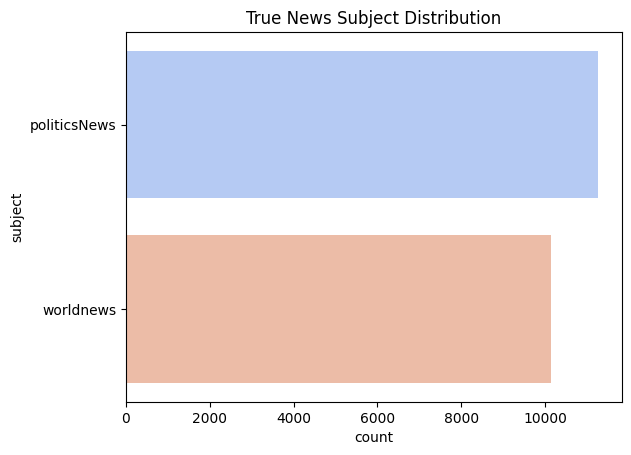

<ipython-input-5-b3d2e6c791a3>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="subject", palette="coolwarm", data=fake_df).set_title('Fake News Subject Distribution')


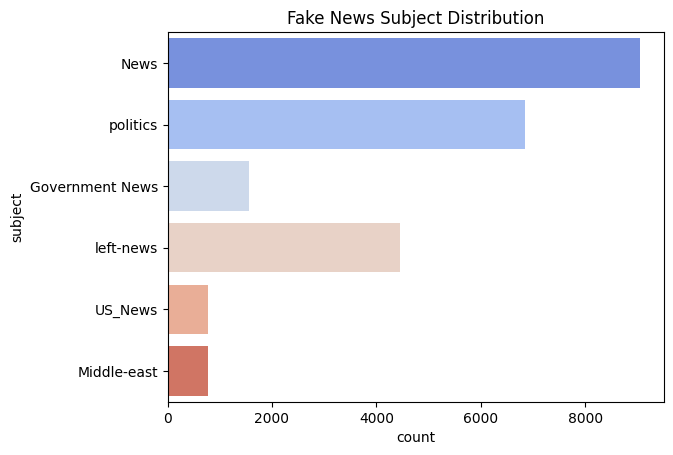

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(y="subject", palette="coolwarm", data=true_df).set_title('True News Subject Distribution')
plt.show()

sns.countplot(y="subject", palette="coolwarm", data=fake_df).set_title('Fake News Subject Distribution')
# sns.countplot(y="subject", palette="coolwarm", data=augmented_fake_df).set_title('Fake News Subject Distribution')
plt.show()

## Real News Word Cloud

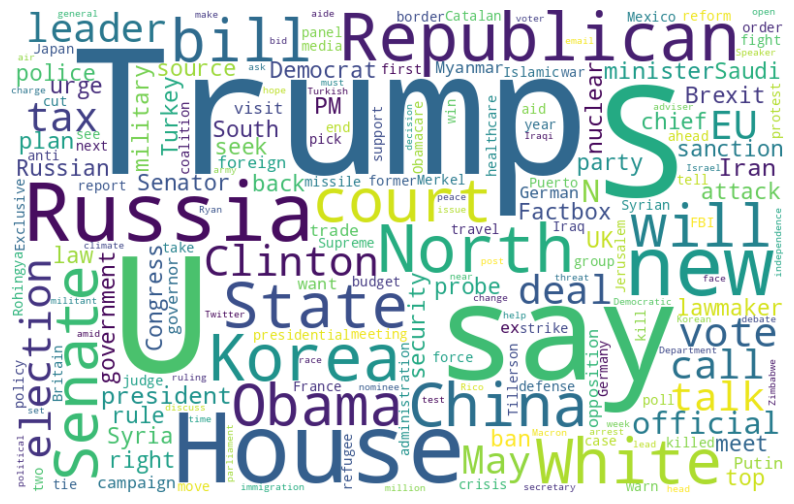

In [6]:
from wordcloud import WordCloud

real_titles = true_df.title
real_titles_ls = [text for text in real_titles]
# print(alls)
real_all_words = ' '.join(real_titles)
wordcloud_real = WordCloud(background_color='white',
    width= 800, height= 500,
    max_font_size = 180,
    collocations = False).generate(real_all_words)

plt.figure(figsize=(10,7))
plt.imshow(wordcloud_real, interpolation='bilinear')
plt.axis("off")
plt.show()

## Fake News Word Cloud

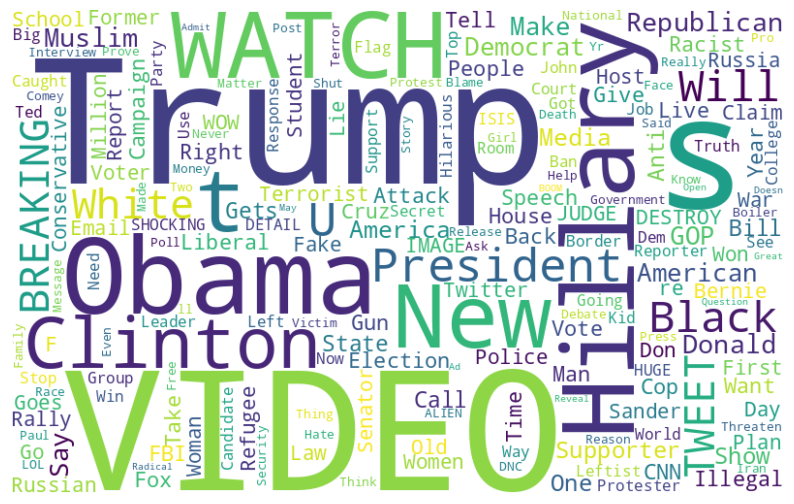

In [7]:
# fake_titles = augmented_fake_df.title
fake_titles = fake_df.title
fake_titles_ls = [text for text in fake_titles]
# print(alls)
fake_all_words = ' '.join(fake_titles)
wordcloud_fake = WordCloud(background_color='white',
    width= 800, height= 500,
    max_font_size = 180,
    collocations = False).generate(fake_all_words)

plt.figure(figsize=(10,7))
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.axis("off")
plt.show()

# Data Preprocessing

## Data Combination

In [8]:
# Add Labels to both df
true_df['true'] = 1
# augmented_fake_df['true'] = 0
fake_df['true'] = 0

# Concat
df = pd.concat([true_df, fake_df])
# df = pd.concat([true_df, augmented_fake_df])
display(df)

,title,text,subject,date,true
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1
...,...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0


## Inspect Lengths of News

In [9]:
titles = [text for text in df.title]

max_len = 0
titles_len = []
for title in titles:
    titles_len.append(len(title.split()))
    max_len = max(len(title.split()), max_len)

print('Number of titles:', len(titles))
print('Max length of the titles:', max_len)
print('Mean length of the titles:', np.mean(titles_len))

Number of titles: 44898
Max length of the titles: 42
Mean length of the titles: 12.453472315025168


<ipython-input-20-48495321f256>:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), rotation=50)


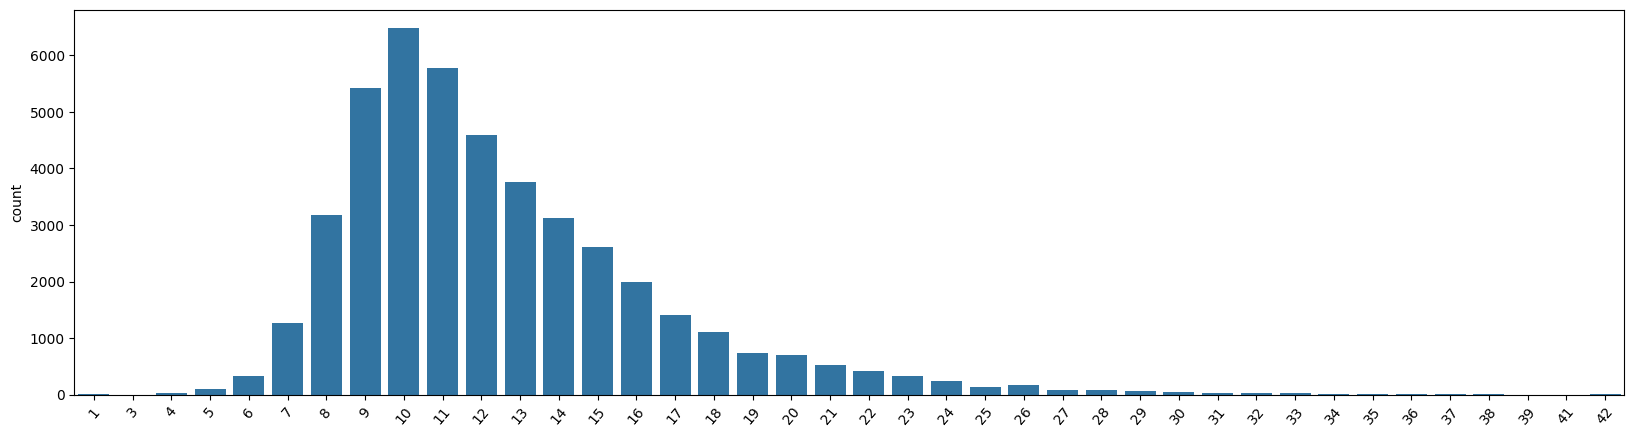

In [20]:
plt.figure(figsize=(20,5))
g = sns.countplot(x=titles_len)
g.set_xticklabels(g.get_xticklabels(), rotation=50)
plt.show()

In [ ]:
texts = [text for text in df.text]

max_len = 0
texts_len = []
for text in texts:
    texts_len.append(len(text.split()))
    max_len = max(len(text.split()), max_len)

# g = sns.countplot(x=texts_len)
print('Mean length of the texts:', np.mean(texts_len))

Mean length of the texts: 405.28228428883244


## Purify & Shffle the DataFrame

In [10]:
from sklearn.utils import shuffle

# Purify
df = df.iloc[:,[1, -1]]

# Drop rows with duplicate titles, keeping the first occurrence
# df = df.drop_duplicates(subset=['title'], keep='first', inplace=True)

# Shuffle
df = shuffle(df).reset_index(drop=True)

display(df)

,text,true
0,"Because today ends in a Y, Donald Trump took t...",0
1,Let s get something straight here Americans ...,0
2,"MANCHESTER, England (Reuters) - British Prime ...",1
3,"WASHINGTON (Reuters) - President Donald Trump,...",1
4,An Oregon judge has had enough of the hillbill...,0
...,...,...
44893,LONDON (Reuters) - U.S. President-elect Donald...,1
44894,"Punishing rich, hard-working, white Americans ...",0
44895,It s pretty common knowledge for anyone s who ...,0
44896,HARARE (Reuters) - Zimbabwe President Robert M...,1


## Split Data into Training, Validation, Test

In [11]:
train_val_df = df.sample(frac = 0.8)
test_df = df.drop(train_val_df.index)

train_df = train_val_df.sample(frac = 0.8)
val_df = train_val_df.drop(train_df.index)

# Reset Index
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('trainset size:', train_df.shape)
print('valset size:', val_df.shape)
print('testset size:', test_df.shape)

trainset size: (28734, 2)
valset size: (7184, 2)
testset size: (8980, 2)


## Dataframe to csv

In [13]:
train_df.to_csv('train.tsv', sep='\t', index=False)
val_df.to_csv('val.tsv', sep='\t', index=False)
test_df.to_csv('test.tsv', sep='\t', index=False)

## Concatenate all dataframe

In [14]:
df = pd.concat([train_df, val_df, test_df])
df

,text,true
0,Donald Trump has had a lot to say about his da...,0
1,Does anyone else find it strange the Obama wou...,0
2,NAIROBI (Reuters) - South Sudan s government h...,1
3,Fresh off its humiliating six-year-long debacl...,0
4,,0
...,...,...
8975,"Unlike the United States, Germany has both a P...",0
8976,WASHINGTON (Reuters) - U.S. President Barack O...,1
8977,CAIRO (Reuters) - Islamic State claimed respon...,1
8978,Great news! A federal judge just ordered the S...,0


## Performing Data Cleaning

In [15]:
# !pip install gensim # Install gensim using pip
import gensim
import nltk
# Downloading Stopwords
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [16]:
# Obtaining Additional Stopwords From nltk
from nltk.corpus import stopwords
stop_words = stopwords.words('english')
stop_words.extend(['from', 'subject', 're', 'edu', 'use'])

In [17]:
# Removing Stopwords And Remove Words With 2 Or Less Characters
def preprocess(text):
    result = []
    for token in gensim.utils.simple_preprocess(text):
        if token not in gensim.parsing.preprocessing.STOPWORDS and len(token) > 3 and token not in stop_words:
            result.append(token)

    return result

In [18]:
import gensim

# Applying The Function To The Dataframe
df['clean'] = df['text'].apply(preprocess)

## Stemming function

In [19]:
# prompt: I have to perform a stemming on the DF data sets title column Write the code for it

from nltk.stem import PorterStemmer

# Initialize the Porter Stemmer
stemmer = PorterStemmer()

# Function to perform stemming on a list of words
def stem_words(words):
    return [stemmer.stem(word) for word in words]

# Apply stemming to the 'clean' column
df['stemmed'] = df['clean'].apply(stem_words)


## Obtaining The Total Words Present In The Dataset

In [20]:
list_of_words = []
for i in df.clean:
    for j in i:
        list_of_words.append(j)

total_words = len(list(set(list_of_words)))
total_words

108258

## Preparing The Data By Performing Tokenization And Padding

In [35]:
from nltk import word_tokenize

In [36]:
from tensorflow.keras.preprocessing.text import one_hot, Tokenizer

# Creating A Tokenizer To Tokenize The Words And Create Sequences Of Tokenized Words
tokenizer = Tokenizer(num_words = total_words)
tokenizer.fit_on_texts(train_df['text'])

train_sequences = tokenizer.texts_to_sequences(train_df['text'])
val_sequences = tokenizer.texts_to_sequences(val_df['text'])
test_sequences = tokenizer.texts_to_sequences(test_df['text'])

In [37]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Adding Padding
padded_train = pad_sequences(train_sequences,maxlen = 42, padding = 'post', truncating = 'post')
padded_val = pad_sequences(val_sequences,maxlen = 42, padding = 'post', truncating = 'post')
padded_test = pad_sequences(test_sequences,maxlen = 42, padding = 'post', truncating = 'post')

# BERT

In [46]:
!pip install transformers

import torch
from transformers import BertTokenizer

In [47]:
PRETRAINED_MODEL_NAME = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(PRETRAINED_MODEL_NAME)

## Load Dataset Class

In [ ]:
from torch.utils.data import Dataset

class FakeNewsDataset(Dataset):
    # def __init__(self, mode, tokenizer):
    def __init__(self, mode, tokenizer, max_len=512): #--------------
        assert mode in ['train', 'val', 'test']
        self.mode = mode
        self.df = pd.read_csv(mode + '.tsv', sep='\t').fillna("")
        self.len = len(self.df)
        self.tokenizer = tokenizer  # BERT tokenizer

        self.max_len = max_len # Store max_len -------------------

    def __getitem__(self, idx):
        if self.mode == 'test':
            statement, label = self.df.iloc[idx, :].values
            label = label if label != '' else '0'
            label_tensor = torch.tensor(int(label))
        else:
            statement, label = self.df.iloc[idx, :].values
            label = label if label != '' else '0'
            label_tensor = torch.tensor(int(label))


        word_pieces = ['[CLS]']
        statement = self.tokenizer.tokenize(statement)
        word_pieces += statement + ['[SEP]']
        len_st = len(word_pieces)

#
        # tokens_b = self.tokenizer.tokenize(text_b)
        # word_pieces += tokens_b + ["[SEP]"]
        # len_b = len(word_pieces) - len_a

        ids = self.tokenizer.convert_tokens_to_ids(word_pieces)
        tokens_tensor = torch.tensor(ids)


        # tokens_tensor = torch.cat([tokens_tensor, torch.zeros(self.max_len - len(tokens_tensor), dtype=torch.long)])
        # segments_tensor = torch.tensor([0] * len_st, dtype=torch.long)
        # segments_tensor = torch.cat([segments_tensor, torch.zeros(self.max_len - len(segments_tensor), dtype=torch.long)])
        # return (tokens_tensor, segments_tensor, label_tensor)

        if len(tokens_tensor) < self.max_len:
            tokens_tensor = torch.cat([tokens_tensor, torch.zeros(self.max_len - len(tokens_tensor), dtype=torch.long)])
        else:
            tokens_tensor = tokens_tensor[:self.max_len]

        segments_tensor = torch.tensor([0] * len_st, dtype=torch.long)
        # Pad or truncate segments_tensor to max_len
        if len(segments_tensor) < self.max_len:
            segments_tensor = torch.cat([segments_tensor, torch.zeros(self.max_len - len(segments_tensor), dtype=torch.long)])
        else:
            segments_tensor = segments_tensor[:self.max_len]


        return (tokens_tensor, segments_tensor, label_tensor)

    def __len__(self):
        return self.len


# Initialize Datasets for Transformation
trainset = FakeNewsDataset('train', tokenizer=tokenizer, max_len=512)
valset = FakeNewsDataset('val', tokenizer=tokenizer, max_len=512)
testset = FakeNewsDataset('test', tokenizer=tokenizer, max_len=512)


print('trainset size:' ,trainset.__len__())
print('valset size:',valset.__len__())
print('testset size: ',testset.__len__())

trainset size: 28734
valset size: 7184
testset size:  8980


## Sampling and Observing Tensors

In [49]:
sample_idx = 0
statement, label = trainset.df.iloc[sample_idx].values
# statement = trainset.df.iloc[sample_idx]['title']
# label = trainset.df.iloc[sample_idx]['true']

tokens_tensor, segments_tensor, label_tensor = trainset[sample_idx]
tokens = tokenizer.convert_ids_to_tokens(tokens_tensor.tolist())
combined_text = " ".join(tokens)

print(f"""
original_statement:
{statement}

tokens:
{tokens}

label: {label}

--------------------

tokens_tensor:
{tokens_tensor}

segments_tensor:
{segments_tensor}

label_tensor:
{label_tensor}

""")


original_statement:
Donald Trump has had a lot to say about his daughter Ivanka and some of his old quotes makes people think he wants to bang her. Actually, the quotes aren t that old.When Trump appeared on  The View  in March 2006 with Ivanka, the alleged billionaire was asked how he would react if Playboy magazine were to ever feature his daughter s picture on its cover. I don t think Ivanka would do that inside the magazine,  Trump said.  Although she does have a very nice figure. I ve said that if Ivanka weren t my daughter, perhaps I would be dating her.  An conservative anti-Trump launched a radio ad earlier this year featuring Trump s bizarre remarks about his daughter.  He told Rolling Stone that if he weren t happily married and his daughter s father,  the narrator says, adding,  he d  well, he didn t finish the thought, but you can guess what he meant.  Trump has made remarks about kissing his daughter, too.We ve all seen the creepy photos of Donald Trump with Ivanka as she

## Reforming the Dataset to Fit the Model

In [50]:
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence


def create_mini_batch(samples):
    tokens_tensors = [s[0] for s in samples]
    segments_tensors = [s[1] for s in samples]


    if samples[0][2] is not None:
        label_ids = torch.stack([s[2] for s in samples])
    else:
        label_ids = None

    # Zero Padding
    tokens_tensors = pad_sequence(tokens_tensors, batch_first=True)
    segments_tensors = pad_sequence(segments_tensors, batch_first=True)


    masks_tensors = torch.zeros(tokens_tensors.shape, dtype=torch.long)
    masks_tensors = masks_tensors.masked_fill(tokens_tensors != 0, 1)

    return tokens_tensors, segments_tensors, masks_tensors, label_ids


BATCH_SIZE = 32
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, collate_fn=create_mini_batch)
valloader = DataLoader(valset, batch_size=BATCH_SIZE, collate_fn=create_mini_batch)
testloader = DataLoader(testset, batch_size=BATCH_SIZE,collate_fn=create_mini_batch)

In [51]:
data = next(iter(trainloader))

tokens_tensors, segments_tensors, masks_tensors, label_ids = data

print(f"""
tokens_tensors.shape   = {tokens_tensors.shape}
{tokens_tensors}
------------------------
segments_tensors.shape = {segments_tensors.shape}
{segments_tensors}
------------------------
masks_tensors.shape    = {masks_tensors.shape}
{masks_tensors}
------------------------
label_ids.shape        = {label_ids.shape}
{label_ids}
""")


tokens_tensors.shape   = torch.Size([32, 512])
tensor([[  101,  6221,  8398,  ...,  1035,  1035,  1035],
        [  101,  2515,  3087,  ...,  1010,  1996,  8112],
        [  101, 21124,  1006,  ...,     0,     0,     0],
        ...,
        [  101,  4924,  1006,  ...,  2004,  1996,  2822],
        [  101,  2196,  2568,  ...,     0,     0,     0],
        [  101,  2096, 15941,  ...,  7807,  2005,  1996]])
------------------------
segments_tensors.shape = torch.Size([32, 512])
tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])
------------------------
masks_tensors.shape    = torch.Size([32, 512])
tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1]])
----------

## Model Construction

In [52]:
from transformers import BertForSequenceClassification
from IPython.display import display, clear_output

PRETRAINED_MODEL_NAME = "bert-base-uncased"
NUM_LABELS = 2

model = BertForSequenceClassification.from_pretrained(
    PRETRAINED_MODEL_NAME, num_labels=NUM_LABELS)

clear_output()
# Step 2: Freeze the first 11 layers of the model
for name, param in model.named_parameters():
    if "encoder.layer" in name:  # Only process layers within the encoder
        layer_num_str = name.split('.')[4]  # Extract layer number string
        if layer_num_str.isdigit():  # Check if it's a number
            layer_num = int(layer_num_str)
            if layer_num < 11:
                param.requires_grad = False


print("""
name             module
-----------------------""")
for name, module in model.named_children():
    if name == "bert":
        for n, _ in module.named_children():
            print(f"{name}:{n}")
    else:
        print("{:16} {}".format(name, module))


name             module
-----------------------
bert:embeddings
bert:encoder
bert:pooler
dropout          Dropout(p=0.1, inplace=False)
classifier       Linear(in_features=768, out_features=2, bias=True)


In [53]:
model.config

BertConfig {
  "_attn_implementation_autoset": true,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "torch_dtype": "float32",
  "transformers_version": "4.51.3",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

# Fine-Tuning of BERT

In [ ]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tqdm.notebook import tqdm
from torch.optim.lr_scheduler import StepLR

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)
model = model.to(device)

# Initialize lists to store metrics
train_losses = []
val_losses = []
train_accs = []
val_accs = []
f1_scores = []
precisions = []
recalls = []
lrs = []
NUM_EPOCHS = 3  # or your desired number of epochs

# Optimizer setup
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
scheduler = StepLR(optimizer, step_size=30, gamma=0.1)

# Training loop
for epoch in range(NUM_EPOCHS):
    # Training phase
    model.train()
    train_loss = 0.0
    train_acc = 0.0
    train_preds = []
    train_true_labels = []

    loop = tqdm(trainloader)
    for batch_idx, data in enumerate(loop):
        tokens_tensors, segments_tensors, masks_tensors, labels = [t.to(device) for t in data]

        optimizer.zero_grad()

        outputs = model(input_ids=tokens_tensors,
                        token_type_ids=segments_tensors,
                        attention_mask=masks_tensors,
                        labels=labels)

        loss = outputs[0]
        loss.backward()
        optimizer.step()

        logits = outputs[1]
        _, pred = torch.max(logits.data, 1)

        train_preds.extend(pred.cpu().tolist())
        train_true_labels.extend(labels.cpu().tolist())

        train_loss += loss.item()

        loop.set_description(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Training")
        loop.set_postfix(loss=train_loss / (batch_idx + 1))

    train_losses.append(train_loss / len(trainloader))
    train_acc = accuracy_score(train_true_labels, train_preds)
    train_accs.append(train_acc)
    train_precision = precision_score(train_true_labels, train_preds)
    train_recall = recall_score(train_true_labels, train_preds)
    train_f1 = f1_score(train_true_labels, train_preds)


    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Training Metrics:")
    print(f"  Loss: {train_losses[-1]:.4f}")
    print(f"  Accuracy: {train_acc:.4f}")
    print(f"  Precision: {train_precision:.4f}")
    print(f"  Recall: {train_recall:.4f}")
    print(f"  F1 Score: {train_f1:.4f}")


    # Validation phase
    model.eval()
    val_loss = 0.0
    val_acc = 0.0
    val_preds = []
    val_true_labels = []

    with torch.no_grad():
        loop_val = tqdm(valloader)
        for batch_idx, data in enumerate(loop_val):
            tokens_tensors, segments_tensors, masks_tensors, labels = [t.to(device) for t in data]

            outputs = model(input_ids=tokens_tensors,
                            token_type_ids=segments_tensors,
                            attention_mask=masks_tensors,
                            labels=labels)

            loss = outputs[0]
            logits = outputs[1]
            _, pred = torch.max(logits.data, 1)

            val_preds.extend(pred.cpu().tolist())
            val_true_labels.extend(labels.cpu().tolist())

            val_loss += loss.item()

            loop_val.set_description(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Validation")
            loop_val.set_postfix(loss=val_loss / (batch_idx + 1))

    val_losses.append(val_loss / len(valloader))
    val_acc = accuracy_score(val_true_labels, val_preds)
    val_accs.append(val_acc)
    val_precision = precision_score(val_true_labels, val_preds)
    val_recall = recall_score(val_true_labels, val_preds)
    val_f1 = f1_score(val_true_labels, val_preds)

    f1_scores.append(val_f1)
    precisions.append(val_precision)
    recalls.append(val_recall)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Validation Metrics:")
    print(f"  Loss: {val_losses[-1]:.4f}")
    print(f"  Accuracy: {val_acc:.4f}")
    print(f"  Precision: {val_precision:.4f}")
    print(f"  Recall: {val_recall:.4f}")
    print(f"  F1 Score: {val_f1:.4f}")


    # Save the model at the end of each epoch
    model_path = os.path.join('/content/drive/MyDrive', f"model_new_epoch_{epoch+1}.pth")
    torch.save(model, model_path)
    print(f"Model saved at {model_path}")

    scheduler.step()
    lrs.append(optimizer.param_groups[0]['lr'])

device: cuda:0


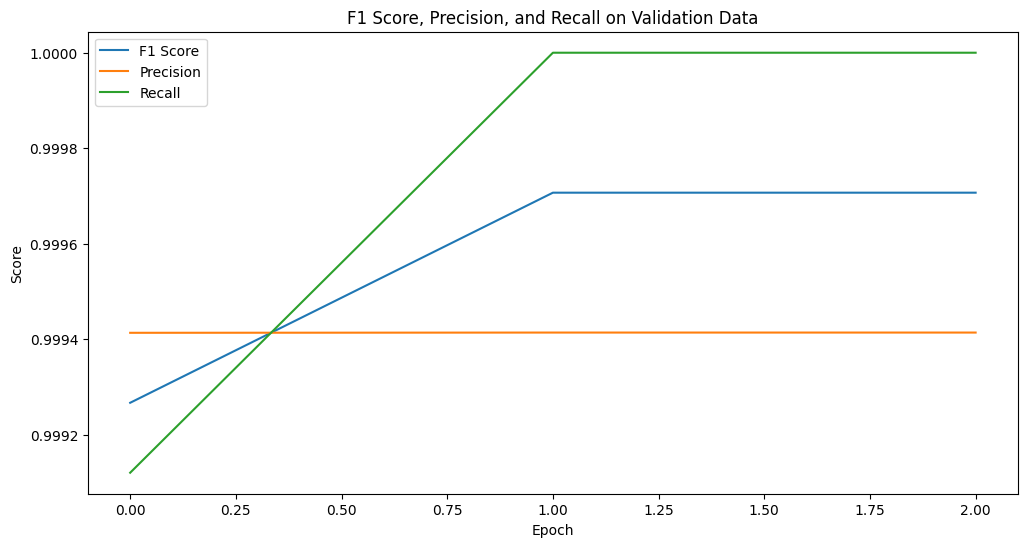

In [ ]:

# Plot F1 Score, Precision, and Recall
plt.figure(figsize=(12, 6))
plt.plot(f1_scores, label='F1 Score')
plt.plot(precisions, label='Precision')
plt.plot(recalls, label='Recall')
plt.title('F1 Score, Precision, and Recall on Validation Data')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.show()

# Training and validation metrics over epochs

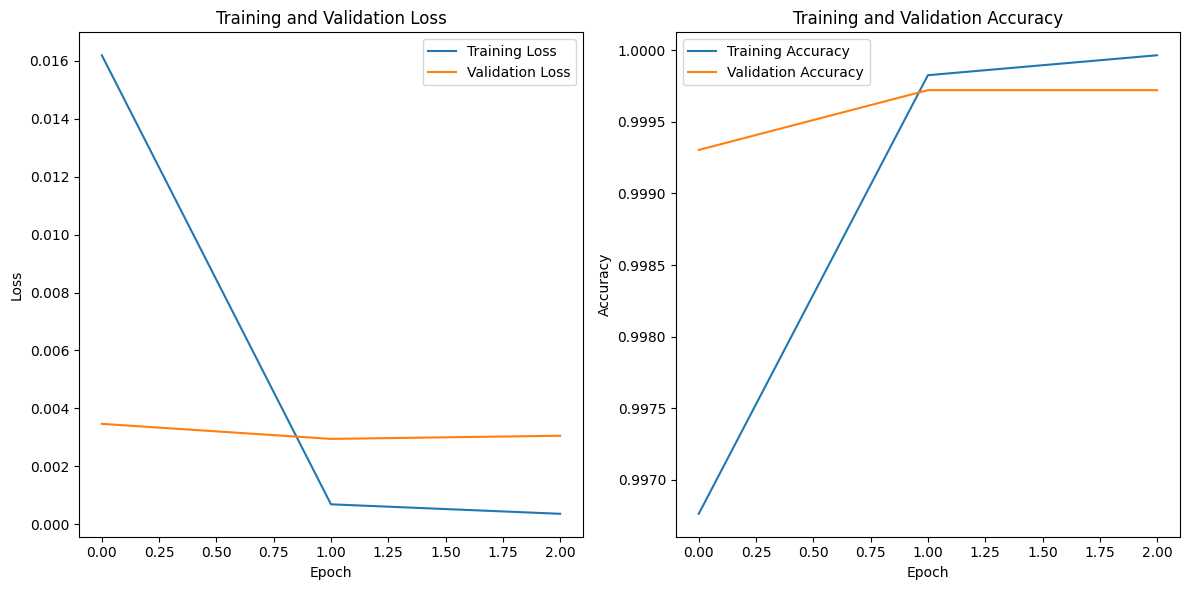

In [ ]:
import matplotlib.pyplot as plt

# Plot Training and Validation Loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Training Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Learning Rate over epoch

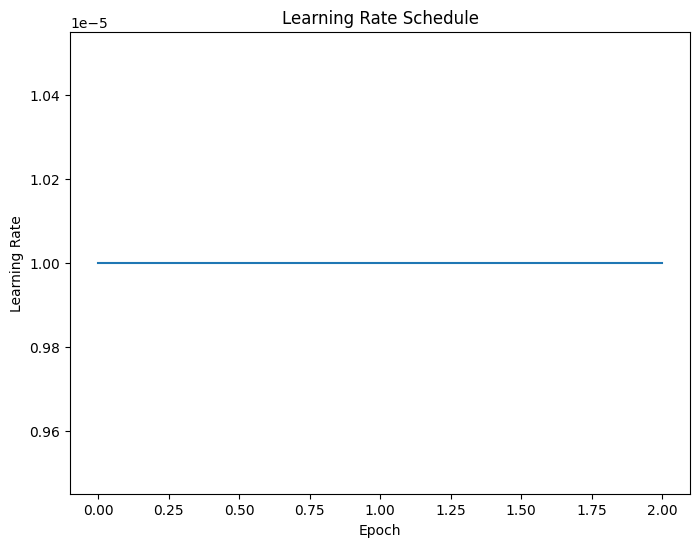

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(lrs)
plt.title('Learning Rate Schedule')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.show()

## Save Model

In [ ]:
# Save the model to your Google Drive
# model_save_path = '/content/drive/MyDrive/0.9985375840889149.pth'  # Change to your desired path
# torch.save(model, model_save_path)

# print(f'Model saved to {model_save_path}!')


## Load Model

##### Download BERT model trained on WELFake dataset
[https://drive.google.com/file/d/1ceHo3p2sA1pVsPFlpbsA09PiBpkPhosx/view?usp=sharing 🔗](https://drive.google.com/file/d/1ceHo3p2sA1pVsPFlpbsA09PiBpkPhosx/view?usp=sharing)

In [ ]:
model = torch.load('/content/drive/MyDrive/ISOT_trained_model.pth', weights_only=False)
model = model.to(device)

# Test

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

true=[]
predictions=[]
with torch.no_grad():
    model.eval()
    for data in testloader:
        if next(model.parameters()).is_cuda:
            data = [t.to(device) for t in data if t is not None]

        tokens_tensors, segments_tensors, masks_tensors = data[:3]
        test_outputs = model(input_ids=tokens_tensors,
                    token_type_ids=segments_tensors,
                    attention_mask=masks_tensors)

        logits = test_outputs[0]
        _, pred = torch.max(logits.data, 1)

        labels = data[3]
        true.extend(labels.cpu().tolist())
        predictions.extend(pred.cpu().tolist())

In [ ]:
# from sklearn.metrics import classification_report # Import the necessary function

# print(classification_report(df_pred.true, df_pred.pred_label))


In [63]:
from sklearn.metrics import classification_report # Import the necessary function
import pandas as pd # Import pandas to create the DataFrame

# ... (Previous code to get 'true' and 'predictions' lists) ...

# Create a DataFrame with the true and predicted labels
df_pred = pd.DataFrame({'true': true, 'pred_label': predictions})

print(classification_report(df_pred.true, df_pred.pred_label))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4721
           1       1.00      1.00      1.00      4259

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



[[1. 0.]
 [0. 1.]]
Acc:  1.0


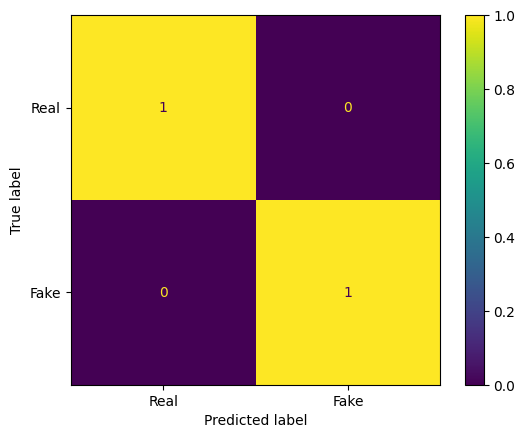

In [64]:
cm = confusion_matrix(true, predictions, labels=[1, 0], normalize='pred')
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
disp.plot()

print('Acc: ', accuracy_score(predictions,true))

# 📊Confusion Matrix

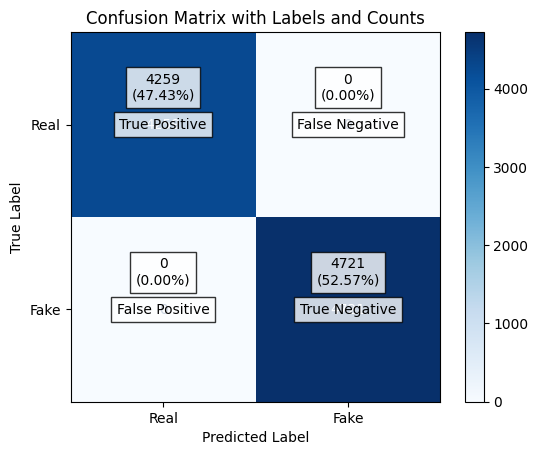

In [65]:
cm = confusion_matrix(true, predictions, labels=[1, 0])

# Create ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])

# Plot the confusion matrix
disp.plot(cmap='Blues', values_format='d') # 'd' for integer format

# Add annotations (labels and counts)
plt.title('Confusion Matrix with Labels and Counts')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        # Display count
        # plt.text(j, i - 0.25, str(cm[i, j]), ha='center', va='center', color='black', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
        # # Display percentage below count
        # plt.text(j, i - 0.15, f'{cm[i, j] / np.sum(cm) * 100:.2f}%', ha='center', va='center', color='black', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))  # Adjust vertical offset as needed

        cell_text = f"{cm[i, j]}\n({cm[i, j] / np.sum(cm) * 100:.2f}%)"
        plt.text(j, i-0.20, cell_text, ha='center', va='center', color='black', fontsize=10,
                 bbox=dict(facecolor='white', alpha=0.8))

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add custom labels for quadrants
plt.text(0, 0, 'True Positive', ha='center', va='center', color='black', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.text(0, 1, 'False Positive', ha='center', va='center', color='black', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.text(1, 0, 'False Negative', ha='center', va='center', color='black', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.text(1, 1, 'True Negative', ha='center', va='center', color='black', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))


plt.show()

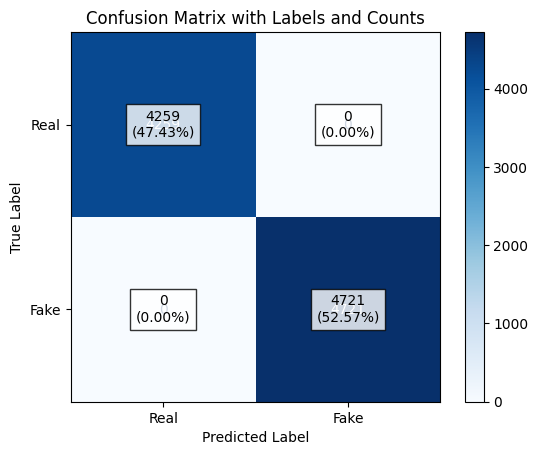

In [66]:
cm = confusion_matrix(true, predictions, labels=[1, 0])

# Create ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])

# Plot the confusion matrix
disp.plot(cmap='Blues', values_format='d')  # 'd' for integer format

# Add annotations (labels and counts)
plt.title('Confusion Matrix with Labels and Counts')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        # Combine count and percentage into a single box
        cell_text = f"{cm[i, j]}\n({cm[i, j] / np.sum(cm) * 100:.2f}%)"
        plt.text(j, i, cell_text, ha='center', va='center', color='black', fontsize=10,
                 bbox=dict(facecolor='white', alpha=0.8))

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

# 📈ROC CURVE and AUC

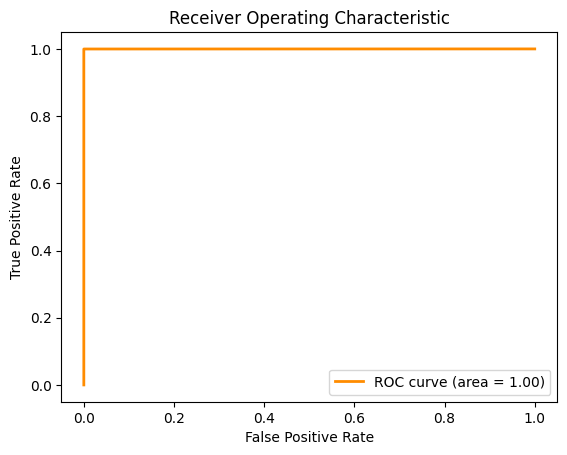

In [ ]:
# Import necessary libraries for ROC curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(true, predictions)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# 📉Precision_recall_curve

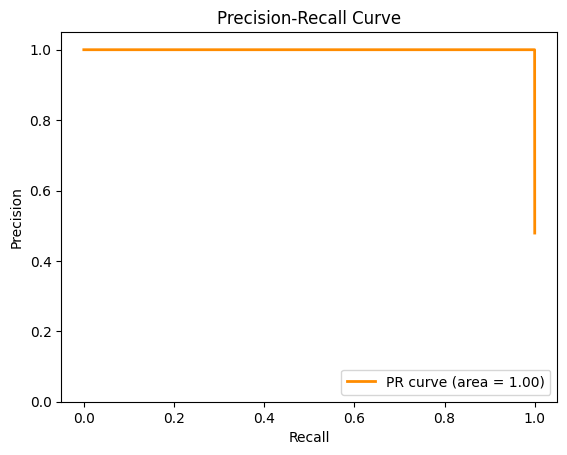

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np


# Get predicted probabilities
probs = []
true_labels = []  # Initialize a list to store true labels for this batch

with torch.no_grad():
    model.eval()
    for data in testloader:
        # ... (Your existing data loading and model prediction code) ...
        tokens_tensors, segments_tensors, masks_tensors, labels = [t.to(device) for t in data]
        test_outputs = model(input_ids=tokens_tensors,
                            token_type_ids=segments_tensors,
                            attention_mask=masks_tensors)
        logits = test_outputs[0]  # Get the model's output logits

        # Get probabilities
        probabilities = torch.softmax(logits, dim=1)
        probs.extend(probabilities.cpu().numpy()[:, 1])  # Get probabilities for class 1

        # Store true labels for this batch
        true_labels.extend(labels.cpu().numpy())

# Calculate precision and recall
precision, recall, _ = precision_recall_curve(true_labels, probs)  # Use accumulated true labels

# Calculate AUC
pr_auc = auc(recall, precision)
# Plot PR curve
plt.figure()
plt.plot(recall, precision, color='darkorange', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlim([-0.05, 1.05])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower right")
plt.show()


#🧭 8. TSNE or PCA Visualizations
TSNE or PCA on BERT embeddings to visualize how well the model clusters fake vs. real news.

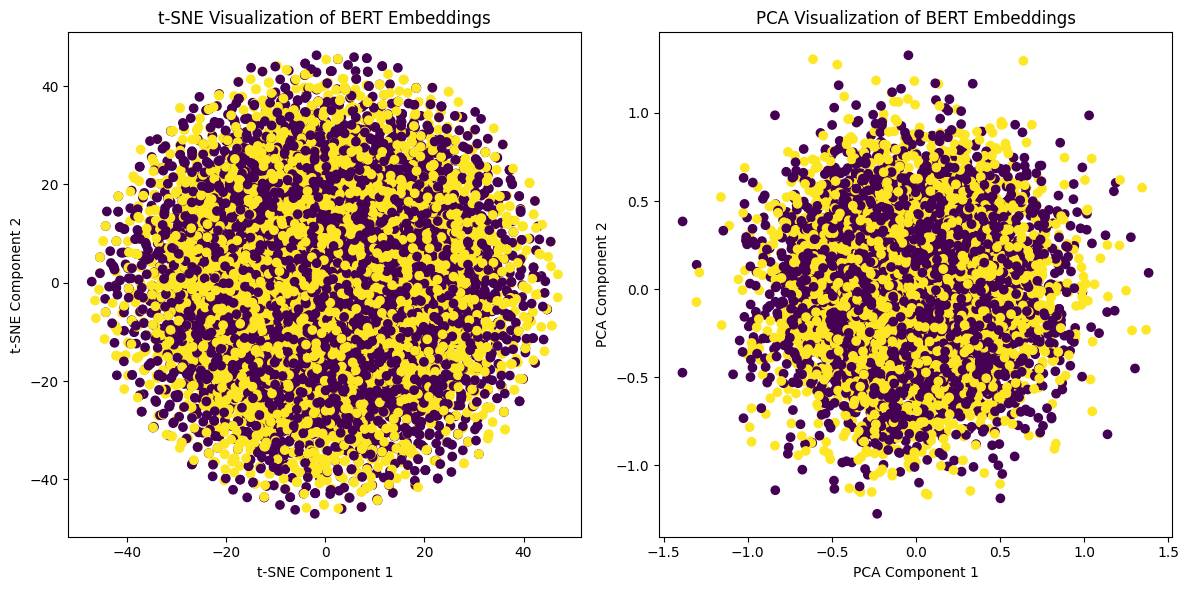

In [ ]:
# prompt: 🧭 8. TSNE or PCA Visualizations
# TSNE or PCA on BERT embeddings to visualize how well the model clusters fake vs. real news.

import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Assuming 'df_pred' contains the predicted labels and the text data
# Replace with your actual dataframe

# Extract embeddings (replace with your actual embedding extraction method)
# Example: Assuming you have a function 'get_embeddings' that returns embeddings
# embeddings = get_embeddings(df_pred['text'])

# Example embeddings (replace with your actual embeddings)
embeddings = np.random.rand(len(df_pred), 768)  # Example: 768-dimensional embeddings

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30) # Adjust perplexity as needed
tsne_embeddings = tsne.fit_transform(embeddings)

# Apply PCA
pca = PCA(n_components=2, random_state=42)
pca_embeddings = pca.fit_transform(embeddings)

# Create visualizations
plt.figure(figsize=(12, 6))

# t-SNE plot
plt.subplot(1, 2, 1)
plt.scatter(tsne_embeddings[:, 0], tsne_embeddings[:, 1], c=df_pred['true']) #'true' column for colors
plt.title('t-SNE Visualization of BERT Embeddings')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

# PCA plot
plt.subplot(1, 2, 2)
plt.scatter(pca_embeddings[:, 0], pca_embeddings[:, 1], c=df_pred['true']) #'true' column for colors
plt.title('PCA Visualization of BERT Embeddings')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.tight_layout()
plt.show()


In [ ]:
# prompt: write a function that take text as a input and give output as true and false that is produced by trained model

import torch
from transformers import BertTokenizer
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from transformers import BertForSequenceClassification

# from google.colab import drive
# drive.mount('/content/drive')

# Load the saved model and tokenizer
# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# model = torch.load('/content/drive/MyDrive/model_epoch_3.pth', weights_only=False) # Replace with your model path
# model = model.to(device)
# tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')


class FakeNewsDataset: # Simplified for prediction
    def __init__(self, statement, tokenizer, max_len=512):
        self.statement = statement
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __getitem__(self, idx):
        word_pieces = ['[CLS]']
        statement = self.tokenizer.tokenize(self.statement)
        word_pieces += statement + ['[SEP]']
        ids = self.tokenizer.convert_tokens_to_ids(word_pieces)
        tokens_tensor = torch.tensor(ids)

        if len(tokens_tensor) < self.max_len:
            tokens_tensor = torch.cat([tokens_tensor, torch.zeros(self.max_len - len(tokens_tensor), dtype=torch.long)])
        else:
            tokens_tensor = tokens_tensor[:self.max_len]

        segments_tensor = torch.tensor([0] * len(word_pieces), dtype=torch.long)
        if len(segments_tensor) < self.max_len:
            segments_tensor = torch.cat([segments_tensor, torch.zeros(self.max_len - len(segments_tensor), dtype=torch.long)])
        else:
            segments_tensor = segments_tensor[:self.max_len]

        return tokens_tensor, segments_tensor


    def __len__(self):
        return 1


def create_mini_batch(samples):
    tokens_tensors = [s[0] for s in samples]
    segments_tensors = [s[1] for s in samples]

    tokens_tensors = pad_sequence(tokens_tensors, batch_first=True)
    segments_tensors = pad_sequence(segments_tensors, batch_first=True)

    masks_tensors = torch.zeros(tokens_tensors.shape, dtype=torch.long)
    masks_tensors = masks_tensors.masked_fill(tokens_tensors != 0, 1)
    return tokens_tensors, segments_tensors, masks_tensors


def predict_fake_news(text):
    dataset = FakeNewsDataset(text, tokenizer)
    loader = DataLoader(dataset, batch_size=1, collate_fn=create_mini_batch)
    with torch.no_grad():
        model.eval()
        for data in loader:
            if next(model.parameters()).is_cuda:
                data = [t.to(device) for t in data]
            tokens_tensors, segments_tensors, masks_tensors = data
            outputs = model(input_ids=tokens_tensors, token_type_ids=segments_tensors, attention_mask=masks_tensors)
            logits = outputs[0]
            _, pred = torch.max(logits.data, 1)
            return bool(pred.item()) # True for fake, False for real

In [ ]:
# Example usage
text="VATICAN CITY (Reuters) - Callista Gingrich, wife of the former speaker of the U.S. House of Representatives, on Friday became U.S. ambassador to the Vatican, which is at odds with Washington over immigration, climate change and Jerusalem. Callista Gingrich, 51, an author, documentary filmmaker and former congressional aide, presented her credentials to Pope Francis at the Vatican to officially assume her role. Her husband Newt Gingrich was an early supporter and vocal ally of U.S. President Donald Trump. Newt Gingrich is expected to continue his role as a political contributor to Fox News from his new base in Rome. Trumpâ€™s nomination of Callista Gingrich to the post at the Holy See in May caused some controversy because of her marriage to Gingrich, with whom she became involved when he was still married to his second wife. Both are Roman Catholic. On Thursday they attended the funeral at the Vatican of Cardinal Bernard Law, who resigned as Archbishop of Boston 15 years ago after covering up years of sexual abuse of children by priests.  The pope has implicitly criticized Trumpâ€™s decision to pull out of the Paris accord on climate change. He said last month that denying climate change or being indifferent to its effects were â€œperverse attitudesâ€ that blocked research and dialogue aimed at protecting the future of the planet. Francis is also opposed to Trumpâ€™s decision to recognize Jerusalem as Israelâ€™s capital. The pontiff has called for respect for the cityâ€™s â€œstatus quo,â€ saying new tension in the Middle East would further inflame world conflicts.. On Thursday at the United Nations, where the Vatican has permanent observer status, more than 120 countries defied Trump and voted in favor of a resolution calling for the United States to drop its recent recognition. The U.S. embassy said in a statement that the new ambassador â€œlooks forward to working with the Holy See to defend human rights, advance religious freedom, combat human trafficking, and to seek peaceful solutions to crises around the worldâ€.    "
prediction = predict_fake_news(text)
print(f"The news is predicted to be fake: {prediction}")

The news is predicted to be fake: True


In [ ]:
# prompt: write a function that take text as a input and give output as true and false that is produced by trained model

import torch
from transformers import BertTokenizer
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from transformers import BertForSequenceClassification

# # Load the saved model and tokenizer
# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# model = torch.load('/content/drive/MyDrive/FakeNewsDetectionFinal/model_epoch_3.pth', weights_only=False) # Replace with your model path
# model = model.to(device)
# tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')


class FakeNewsDataset: # Simplified for prediction
    def __init__(self, statement, tokenizer, max_len=512):
        self.statement = statement
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __getitem__(self, idx):
        word_pieces = ['[CLS]']
        statement = self.tokenizer.tokenize(self.statement)
        word_pieces += statement + ['[SEP]']
        ids = self.tokenizer.convert_tokens_to_ids(word_pieces)
        tokens_tensor = torch.tensor(ids)

        if len(tokens_tensor) < self.max_len:
            tokens_tensor = torch.cat([tokens_tensor, torch.zeros(self.max_len - len(tokens_tensor), dtype=torch.long)])
        else:
            tokens_tensor = tokens_tensor[:self.max_len]

        segments_tensor = torch.tensor([0] * len(word_pieces), dtype=torch.long)
        if len(segments_tensor) < self.max_len:
            segments_tensor = torch.cat([segments_tensor, torch.zeros(self.max_len - len(segments_tensor), dtype=torch.long)])
        else:
            segments_tensor = segments_tensor[:self.max_len]

        return tokens_tensor, segments_tensor


    def __len__(self):
        return 1


def create_mini_batch(samples):
    tokens_tensors = [s[0] for s in samples]
    segments_tensors = [s[1] for s in samples]

    tokens_tensors = pad_sequence(tokens_tensors, batch_first=True)
    segments_tensors = pad_sequence(segments_tensors, batch_first=True)

    masks_tensors = torch.zeros(tokens_tensors.shape, dtype=torch.long)
    masks_tensors = masks_tensors.masked_fill(tokens_tensors != 0, 1)
    return tokens_tensors, segments_tensors, masks_tensors

def predict_fake_news(text):
    dataset = FakeNewsDataset(text, tokenizer)
    loader = DataLoader(dataset, batch_size=1, collate_fn=create_mini_batch)
    with torch.no_grad():
        model.eval()
        for data in loader:
            if next(model.parameters()).is_cuda:
                data = [t.to(device) for t in data]
            tokens_tensors, segments_tensors, masks_tensors = data
            outputs = model(input_ids=tokens_tensors, token_type_ids=segments_tensors, attention_mask=masks_tensors)
            logits = outputs[0]
            probabilities = torch.softmax(logits, dim=1) # Get probabilities
            confidence_true = probabilities[0][0].item()  # Confidence for true
            confidence_fake = probabilities[0][1].item()  # Confidence for fake

            return confidence_true, confidence_fake # Return both confidences


0

In [ ]:
text = "Wisconsin is on pace to double the number of layoffs this year."
preciconfidence_true, confidence_fake = predict_fake_news(text)
print(f"Confidence for True: {confidence_true:.4f}")
print(f"Confidence for Fake: {confidence_fake:.4f}")


## Insight on Wrong Classification

<ipython-input-63-4fe9ad7547fc>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="true", palette="coolwarm", data=wrong_df).set_title('Wrong Classification Result Real/Fake Distribution')


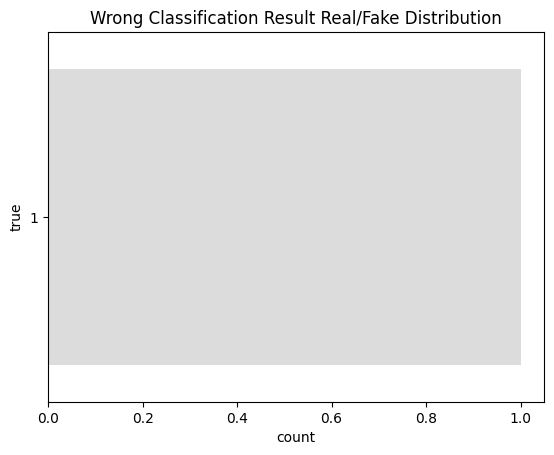

In [ ]:
wrong_df = df_pred[df_pred.true != df_pred.pred_label]
sns.countplot(y="true", palette="coolwarm", data=wrong_df).set_title('Wrong Classification Result Real/Fake Distribution')
plt.show()

In [ ]:
wrong_titles = df_pred[df_pred.true != df_pred.pred_label].text.values
wrong_titles

AttributeError: 'DataFrame' object has no attribute 'text'

<ipython-input-65-58666c30eb50>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="true", palette="coolwarm", data=wrong_df).set_title('Wrong Classification Result Real/Fake Distribution')


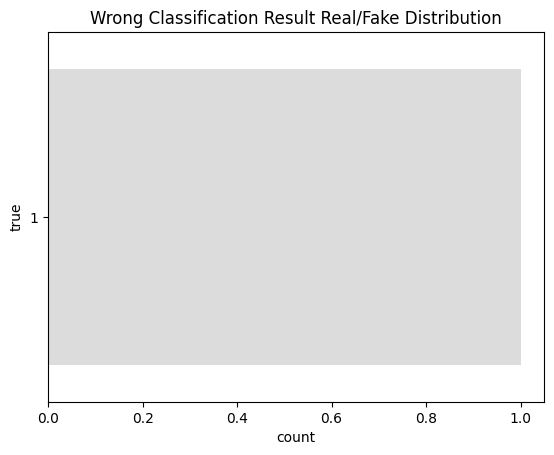

In [ ]:
# Assuming 'df' is your original DataFrame containing the 'text' column and 'true' labels
# Make sure 'df' is available in your current environment

# Before creating df_pred, you need to make sure you have the original text and true labels together
# Since df was already created and contains the text and true labels, we can merge or join.
# However, a simpler approach is to add the predicted labels directly to the original df
# after splitting and predicting on the test set.

# Recreate df_pred by adding the predicted labels to the test_df
test_df['pred_label'] = predictions

# Now df_pred (which is essentially the test_df with predictions) has the 'text' column
wrong_df = test_df[test_df.true != test_df.pred_label]
sns.countplot(y="true", palette="coolwarm", data=wrong_df).set_title('Wrong Classification Result Real/Fake Distribution')
plt.show()